In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("ai4i2020.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (10000, 14)


In [3]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Remove unnecessary identification columns
df = df.drop(["UDI", "Product ID"], axis=1)

# Encode the Type column
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])

print("Preprocessing completed successfully!")
print("Remaining columns:")
print(df.columns.tolist())

Preprocessing completed successfully!
Remaining columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [5]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

print("Features selected:")
print(X.columns.tolist())

print("\nTarget:", y.name)

Features selected:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Target: Machine failure


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 99.9 %


Confusion Matrix:
[[1932    0]
 [   2   66]]


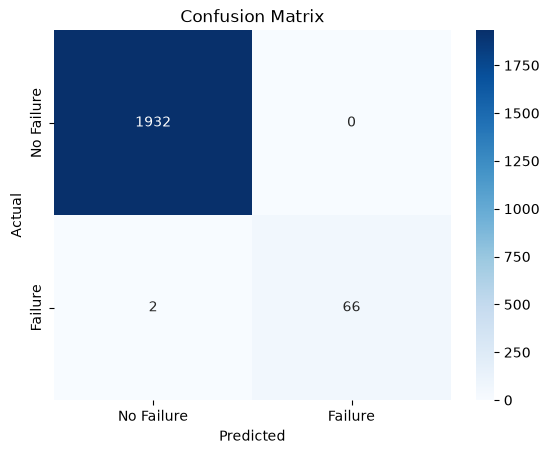

In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



Actual vs Predicted Failure:
   Actual  Predicted  Count
0       0          0   1932
1       1          1     66
2       1          0      2


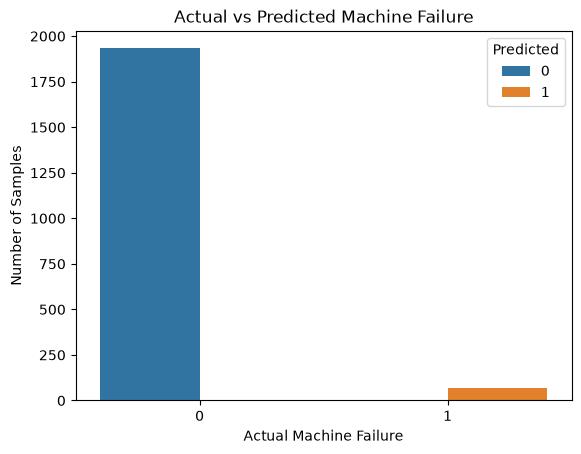

In [14]:
id="actualvspred"
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison_counts = comparison.value_counts().reset_index()
comparison_counts.columns = ["Actual", "Predicted", "Count"]

print("Actual vs Predicted Failure:")
print(comparison_counts)

sns.barplot(
    data=comparison_counts,
    x="Actual",
    y="Count",
    hue="Predicted"
)

plt.xlabel("Actual Machine Failure")
plt.ylabel("Number of Samples")
plt.title("Actual vs Predicted Machine Failure")
plt.show()

In [17]:
# Test a new machine condition

new_machine = pd.DataFrame({
    "Type": [1],
    "Air temperature [K]": [300],
    "Process temperature [K]": [310],
    "Rotational speed [rpm]": [1400],
    "Torque [Nm]": [50],
    "Tool wear [min]": [200],
    "TWF": [0],
    "HDF": [0],
    "PWF": [0],
    "OSF": [1],
    "RNF": [0]
})

prediction = model.predict(new_machine)
failure_probability = model.predict_proba(new_machine)[0][1]

print("NEW MACHINE PREDICTION")
print("----------------------")

if prediction[0] == 1:
    print("Status: MACHINE FAILURE")
    print("Recommendation: Maintenance required.")
else:
    print("Status: NORMAL")
    print("Recommendation: Machine can continue operation.")

print("Failure Probability:", round(failure_probability * 100, 2), "%")

NEW MACHINE PREDICTION
----------------------
Status: MACHINE FAILURE
Recommendation: Maintenance required.
Failure Probability: 95.0 %


Feature Importance:
                    Feature  Importance
7                       HDF    0.272093
9                       OSF    0.232373
8                       PWF    0.200104
6                       TWF    0.108812
4               Torque [Nm]    0.076630
3    Rotational speed [rpm]    0.044600
5           Tool wear [min]    0.028837
1       Air temperature [K]    0.017290
2   Process temperature [K]    0.015728
0                      Type    0.003187
10                      RNF    0.000345


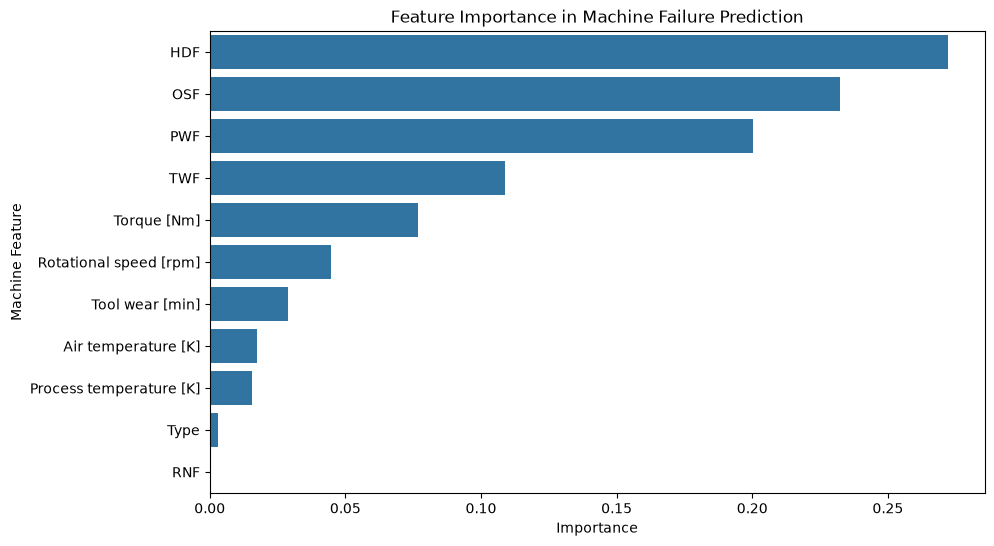

In [18]:
# Feature Importance Analysis

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance", ascending=False
)

print("Feature Importance:")
print(importance)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.xlabel("Importance")
plt.ylabel("Machine Feature")
plt.title("Feature Importance in Machine Failure Prediction")
plt.show()

In [19]:
# Final Predictive Maintenance Decision

print("====================================")
print("   PREDICTIVE MAINTENANCE RESULT")
print("====================================")

if prediction[0] == 1:
    print("Machine Status      : FAILURE")
    print("Failure Probability :",
          round(failure_probability * 100, 2), "%")
    print("Recommended Action  : Maintenance required.")
else:
    print("Machine Status      : NORMAL")
    print("Failure Probability :",
          round(failure_probability * 100, 2), "%")
    print("Recommended Action  : Machine can continue operation.")

print("====================================")

   PREDICTIVE MAINTENANCE RESULT
Machine Status      : FAILURE
Failure Probability : 95.0 %
Recommended Action  : Maintenance required.
